# MMI 2 X 2

1. Importamos las librerías

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


In [2]:
import importlib
import upvfab_design_tools

importlib.reload(upvfab_design_tools)
from upvfab_design_tools import MMI_EME, DC_EME
import gplugins.tidy3d.materials as mat


2. Sacamos los indices refractivos de los maeriales

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

# Diseño MMI 2 X 2

In [7]:

# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 5.5 # Student. Body width

# m = MMI_EME(VERBOSE=True)  ## --> Para ver el indice efectivo de cada uno de los modos que se propagan 
m = MMI_EME(Show_Propagation_Plot=True,VERBOSE_ratios=True) # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 0.5 # Ancho adicional de la guia para que sea del tamaño del taper
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  48.81383142685599  µm


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

------- Pameters -------
MMI length 24.4069
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9804
Total OUT power: 0.9438
Excess loss [dB] =  0.1654
------------------------
Power over OUTs:  ['0.4689', '0.4749']
Ratio over OUTs ['0.4968', '0.5032']
Phase over OUTs ['-91.9864', '-177.1788']


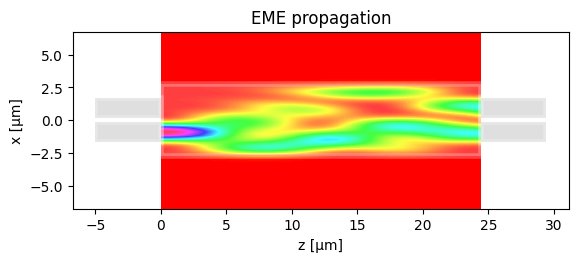

In [8]:
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT


# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6])  # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6])  # STUDENT

m.L_MMI = L_pi/2
# MMI length (check class slides for type of MMI)
#m.dL_MMI = -0.15 # STUDENT

# Run propagation
power, power_total,power_in, phase=m.propagation()


# Oprimización del MMI 2 X 2

1. Se define el MMI 2X2 para que no grafique ni saque texto, de manera que las simulaciones sean más eficientes y rápidas 

In [4]:

# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 5.5 # Student. Body width

# m = MMI_EME(VERBOSE=True)  ## --> Para ver el indice efectivo de cada uno de los modos que se propagan 
m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 0.5 # Ancho adicional de la guia para que sea del tamaño del taper
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  48.8138314268635  µm


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


2. Se define como van a ser los casos de movimiento de las guías:

Caso 1:

    ------   output 1 -> -1/4 - dy_outs_2x2
    ------   output 2 ->  1/4 + dy_outs_2x2


    ------   input 1 -> 0
    ------   input 2 -> 0 

Caso 2:

    ------   output 1 -> -1/4 - dy_outs_2x2
    ------   output 2 ->  1/4 + dy_outs_2x2


    ------   input 1 -> 0 - dy_input_2x2
    ------   input 2 -> 0 + dy_input_2x2



Así, el caso 1 es el siguiente:

In [5]:

m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

array_power_out=[]
array_power_in=[]
array_EL=[]
array_DL_MMI=[]
array_power_out1=[]
array_power_out2=[]
array_phase_out1=[]
array_phase_out2=[]
array_phase_o1_o2=[]


for i in range(-10,20,1):
    
    dy_out = i/100
    dy_input=0

    m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy_input, dy_input]) 
    m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy_out, dy_out]) 

    m.L_MMI = L_pi/2

    power, power_total,power_in, phase=m.propagation()

    Loss = 10 * np.log10(power_in / power_total)
    array_EL.append(Loss)

    array_DL_MMI.append(i/100)
    array_power_out1.append((power[0]*100)/power_total)
    array_power_out2.append((power[1]*100)/power_total)



  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

...

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

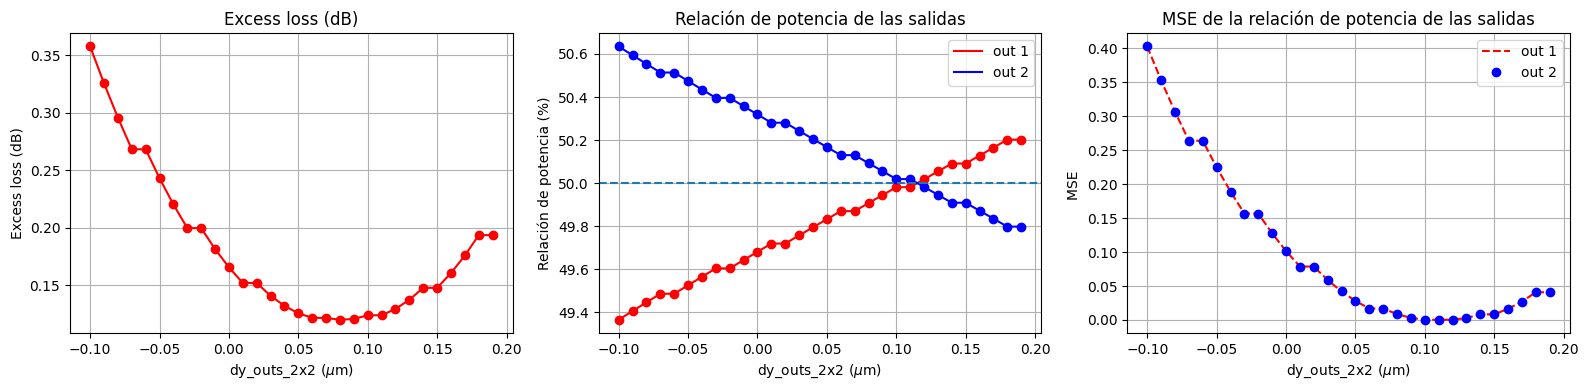

In [7]:

fig, axs = plt.subplots(1, 3, figsize=(16, 4))


axs[0].plot(array_DL_MMI, array_EL, 'r') 
axs[0].plot(array_DL_MMI, array_EL, 'o',linestyle='None',color='r') 
axs[0].set_title('Excess loss (dB)')
axs[0].set_xlabel(r'dy_outs_2x2 ($\mu$m)')
axs[0].set_ylabel('Excess loss (dB)')
axs[0].grid(True)

axs[1].plot(array_DL_MMI, array_power_out1, 'r',label='out 1') 
axs[1].plot(array_DL_MMI, array_power_out2, 'b',label='out 2')
axs[1].plot(array_DL_MMI, array_power_out1, 'o',color='r',linestyle='None') 
axs[1].plot(array_DL_MMI, array_power_out2, 'o',color='b',linestyle='None')
axs[1].axhline(y=50, linestyle='--', linewidth=1.5)
axs[1].ticklabel_format(axis='y', style='plain', useOffset=False)
axs[1].set_title('Relación de potencia de las salidas')
axs[1].set_xlabel(r'dy_outs_2x2 ($\mu$m)')
axs[1].set_ylabel('Relación de potencia (%)')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(array_DL_MMI, (np.array(array_power_out1)-50)**2, 'r--',label='out 1') 
axs[2].plot(array_DL_MMI, (np.array(array_power_out2)-50)**2, 'o',label='out 2',color='b')
#axs[2].ticklabel_format(axis='y', style='plain', useOffset=False)
axs[2].set_title('MSE de la relación de potencia de las salidas')
axs[2].set_xlabel(r'dy_outs_2x2 ($\mu$m)')
axs[2].set_ylabel(r'MSE ') #($\times 10^{-4}$)
axs[2].legend()
axs[2].grid(True)



plt.tight_layout()

plt.show()

In [14]:
print("Las perdidas mínimas son de: ", np.round(array_EL[18],4))
print("Las perdidas mínimas se dan para dy_outs_2x2 de: ", np.round(array_DL_MMI[18],4))
print("El valor mínimo de relación de potencias es: ", np.round(array_power_out1[18],4))
print("El valor máximo de relación de potencias es: ", np.round(array_power_out2[18],4))
print("El MSE del valor mínimo de relación de potencias es: ", np.round((array_power_out1[18]-50)**2,4))
print("El MSE del valor máximo de relación de potencias es: ", np.round((array_power_out2[18]-50)**2,4))
print(" ")
print("Para el valor de mejor relación de potencias: ")
print("Las perdidas son de: ", np.round(array_EL[21],4))
print("Estas perdidas se dan para dy_outs_2x2 de: ", np.round(array_DL_MMI[21],4))
print("El valor mínimo de relación de potencias es: ", np.round(array_power_out1[21],4))
print("El valor máximo de relación de potencias es: ", np.round(array_power_out1[21],4))
print("El MSE del valor mínimo de relación de potencias es: ", np.round((array_power_out1[21]-50)**2,4))
print("El MSE del valor máximo de relación de potencias es: ", np.round((array_power_out1[21]-50)**2,4))

Las perdidas mínimas son de:  0.1198
Las perdidas mínimas se dan para dy_outs_2x2 de:  0.08
El valor mínimo de relación de potencias es:  49.9071
El valor máximo de relación de potencias es:  50.0929
El MSE del valor mínimo de relación de potencias es:  0.0086
El MSE del valor máximo de relación de potencias es:  0.0086
 
Para el valor de mejor relación de potencias: 
Las perdidas son de:  0.1237
Estas perdidas se dan para dy_outs_2x2 de:  0.11
El valor mínimo de relación de potencias es:  49.9811
El valor máximo de relación de potencias es:  49.9811
El MSE del valor mínimo de relación de potencias es:  0.0004
El MSE del valor máximo de relación de potencias es:  0.0004


En este caso, es importante notar que la relación de potencias si varía más que en el caso del MMI 1 X 2, pasando de los 49.4% a los 50.6%, aunque la diferencia de tomar el punto de minima potencia o el de mejor relación de fases no varia mucho los resultados, así que en este caso se toma el de menores perdidas.

Caso 2:

In [15]:
m.n_IN = 2 
m.n_OUT = 2 


dy2_vals = np.arange(0, 10, 1) / 100  
dy1_vals = np.arange(0, 10, 1) / 100  


shape_2d = (len(dy2_vals), len(dy1_vals))

Loss_matrix   = np.zeros(shape_2d)
p1_matrix     = np.zeros(shape_2d)
p2_matrix     = np.zeros(shape_2d)
phase1_matrix     = np.zeros(shape_2d)
phase2_matrix     = np.zeros(shape_2d)
diff12_matrix = np.zeros(shape_2d)


for j_idx, j in enumerate(range(0, 10, 1)):
    for i_idx, i in enumerate(range(0, 10, 1)):

        m.L_MMI = L_pi/2
        dy_input_c2 = i/100 
        dy_out_c2 = j/100

        m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy_input_c2, dy_input_c2]) # STUDENT
        m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy_out_c2, dy_out_c2]) # STUDENT
        power, power_total, power_in, phase = m.propagation()
       
        Loss = 10 * np.log10(power_in / power_total)
        Loss_matrix[j_idx, i_idx] = Loss

        p1_matrix[j_idx, i_idx]   = (power[0]*100) / power_total
        p2_matrix[j_idx, i_idx]   = (power[1]*100) / power_total
        
        phase1_matrix[j_idx, i_idx] = phase[0]
        phase2_matrix[j_idx, i_idx] = phase[1]

        diff12_matrix[j_idx, i_idx] = phase[1] - phase[0]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

...

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

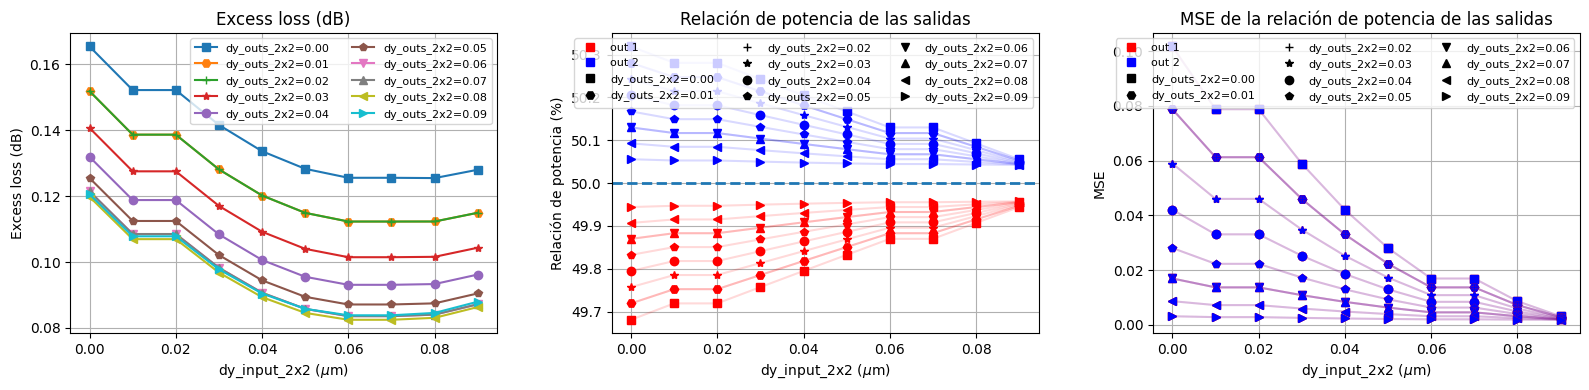

In [17]:

fig, axs = plt.subplots(1, 3, figsize=(16, 4))

#opacidades = [0.3, 0.5, 0.7, 0.9, 1.0] 
opacidades = [1, 1, 1, 1, 1,1] 
#marcadores = ['s', 'H', '+', '*', 'o','p']
linest=['-','--','-.',':','-']
#linest=['None','None','None','None','None','None']
marcadores = ['s', 'H', '+', '*', 'o', 'p', 'v', '^', '<', '>', 'X'][:len(dy2_vals)]

for j_idx, dy2 in enumerate(dy2_vals):
    lbl_dy2 = f"dy_outs_2x2={dy2:.2f}"
    #alpha = opacidades[j_idx]
    mkr = marcadores[j_idx]
    #ls=linest[j_idx]
    alpha = 0.15
    ls = '-'

    axs[0].plot(dy1_vals, Loss_matrix[j_idx, :], marker=mkr, linestyle='-',label=lbl_dy2)

    if j_idx == 0:
        axs[1].plot(dy1_vals, p1_matrix[j_idx, :], 'r', marker=mkr, alpha=alpha, linestyle=ls )
        axs[1].plot(dy1_vals, p2_matrix[j_idx, :], 'b', marker=mkr, alpha=alpha, linestyle=ls )
        axs[1].plot(dy1_vals, p1_matrix[j_idx, :], 'r', marker=mkr, linestyle='None',label='out 1')
        axs[1].plot(dy1_vals, p2_matrix[j_idx, :], 'b', marker=mkr, linestyle='None',label='out 2')
        axs[2].plot(dy1_vals, (np.array(p1_matrix[j_idx, :])-50)**2, 'r', marker=mkr, alpha=alpha, linestyle=ls )
        axs[2].plot(dy1_vals, (np.array(p2_matrix[j_idx, :])-50)**2, 'b', marker=mkr, alpha=alpha, linestyle=ls )
        axs[2].plot(dy1_vals, (np.array(p1_matrix[j_idx, :])-50)**2, 'r', marker=mkr, linestyle='None',label='out 1')
        axs[2].plot(dy1_vals, (np.array(p2_matrix[j_idx, :])-50)**2, 'b', marker=mkr, linestyle='None',label='out 2')
    else:
        axs[1].plot(dy1_vals, p1_matrix[j_idx, :], 'r', marker=mkr, linestyle=ls , alpha=alpha)
        axs[1].plot(dy1_vals, p2_matrix[j_idx, :], 'b', marker=mkr, linestyle=ls , alpha=alpha)
        axs[1].plot(dy1_vals, p1_matrix[j_idx, :], 'r', marker=mkr, linestyle='None')
        axs[1].plot(dy1_vals, p2_matrix[j_idx, :], 'b', marker=mkr, linestyle='None')
        axs[2].plot(dy1_vals, (np.array(p1_matrix[j_idx, :])-50)**2, 'r', marker=mkr, alpha=alpha, linestyle=ls )
        axs[2].plot(dy1_vals, (np.array(p2_matrix[j_idx, :])-50)**2, 'b', marker=mkr, alpha=alpha, linestyle=ls )
        axs[2].plot(dy1_vals, (np.array(p1_matrix[j_idx, :])-50)**2, 'r', marker=mkr, linestyle='None')
        axs[2].plot(dy1_vals, (np.array(p2_matrix[j_idx, :])-50)**2, 'b', marker=mkr, linestyle='None')
            

    axs[1].plot([], [], color='black', marker=mkr, linestyle='None', label=lbl_dy2)
    axs[2].plot([], [], color='black', marker=mkr, linestyle='None', label=lbl_dy2)


axs[0].set_title('Excess loss (dB)')
axs[0].set_xlabel(r'dy_input_2x2 ($\mu$m)')
axs[0].set_ylabel('Excess loss (dB)')
axs[0].grid(True)
axs[0].legend(fontsize='8', ncol=2)

 
axs[1].axhline(y=50, linestyle='--', linewidth=2)
axs[1].set_title('Relación de potencia de las salidas')
axs[1].set_xlabel(r'dy_input_2x2 ($\mu$m)')
axs[1].set_ylabel('Relación de potencia (%)')
#axs[1].set_ylim(y_min,y_max)
axs[1].grid(True)
axs[1].legend(fontsize='8', ncol=3) 


#axs[2].ticklabel_format(axis='y', style='plain', useOffset=False)
axs[2].set_title('MSE de la relación de potencia de las salidas')
axs[2].set_xlabel(r'dy_input_2x2 ($\mu$m)')
axs[2].set_ylabel(r'MSE')
axs[2].legend()
axs[2].grid(True)
axs[2].legend(fontsize='8', ncol=3) 

plt.tight_layout()
plt.show()

Como se observa, para el valor dy_out_2x2, se obtienen los mejores resultados para el caso de 0.09 y para dy_input_2x2=0.06, pues en este se encuentra un mejor balance de potencias y unas menores perdidas de exceso.

In [22]:
print('Las menores perdidas son: ', np.round(min(Loss_matrix[9, :]),3), " dB. Para un valor de dy_input_c2 = ", dy1_vals[6] )
print('El valor mínimo de la relación de potencias es: ', np.round( p1_matrix[9,6],3 ))
print('El valor máximo de la relación de potencias es: ', np.round( p2_matrix[9,6],3 ))

Las menores perdidas son:  0.084  dB. Para un valor de dy_input_c2 =  0.06
El valor mínimo de la relación de potencias es:  49.955
El valor máximo de la relación de potencias es:  50.045


<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_186619/768409224.py:39: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('dy_input_c2 ($\mu$m)')


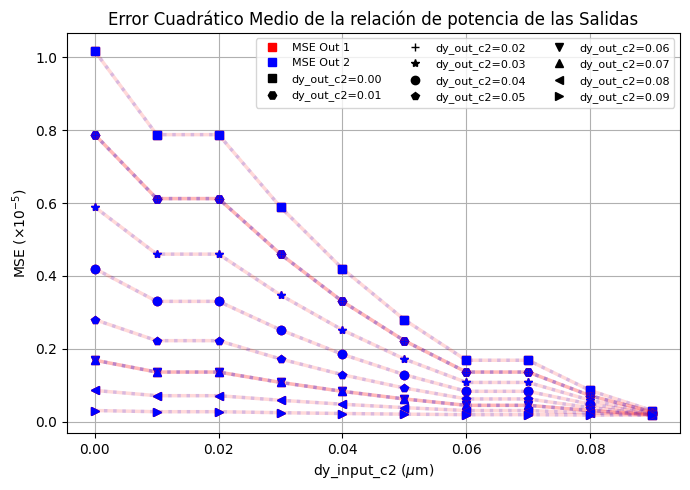

In [35]:


plt.figure(figsize=(7, 5))


dy1_vals_np = np.array(dy1_vals)

marcadores = ['s', 'H', '+', '*', 'o', 'p', 'v', '^', '<', '>', 'X'][:len(dy2_vals)]
alpha = 0.15
ls = '-'
ls2=':'

for j_idx, dy2 in enumerate(dy2_vals):
    lbl_dy2 = f"dy_out_c2={dy2:.2f}"
    mkr = marcadores[j_idx]
    
    
    mse1_row = ((np.array(p1_matrix[j_idx, :]) - 0.5) ** 2) * 1e5
    mse2_row = ((np.array(p2_matrix[j_idx, :]) - 0.5) ** 2) * 1e5

    
    if j_idx == 0:
        plt.plot(dy1_vals_np, mse1_row, 'r', marker=mkr, alpha=alpha, linestyle=ls,linewidth=2.5)
        plt.plot(dy1_vals_np, mse2_row, 'b', marker=mkr, alpha=alpha, linestyle=ls2,linewidth=2.5)
        plt.plot(dy1_vals_np, mse1_row, 'r', marker=mkr, linestyle='None', label='MSE Out 1')
        plt.plot(dy1_vals_np, mse2_row, 'b', marker=mkr, linestyle='None', label='MSE Out 2')
    else:
        plt.plot(dy1_vals_np, mse1_row, 'r', marker=mkr, linestyle=ls, alpha=alpha,linewidth=2.5)
        plt.plot(dy1_vals_np, mse2_row, 'b', marker=mkr, linestyle=ls2, alpha=alpha,linewidth=2.5)
        plt.plot(dy1_vals_np, mse1_row, 'r', marker=mkr, linestyle='None')
        plt.plot(dy1_vals_np, mse2_row, 'b', marker=mkr, linestyle='None')
        
    
    plt.plot([], [], color='black', marker=mkr, linestyle='None', label=lbl_dy2)


plt.ticklabel_format(axis='y', style='plain')


plt.title('Error Cuadrático Medio de la relación de potencia de las Salidas')
plt.xlabel('dy_input_c2 ($\mu$m)')
plt.ylabel(r'MSE ($\times 10^{-5}$)')
plt.grid(True)
plt.legend(fontsize='8', ncol=3) 


plt.tight_layout()
plt.show()

### 2. variación de la longitud del MMI

1. Primero definimos el MMI

In [23]:

# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 5.5 # Student. Body width

# m = MMI_EME(VERBOSE=True)  ## --> Para ver el indice efectivo de cada uno de los modos que se propagan 
m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 0.5 # Ancho adicional de la guia para que sea del tamaño del taper
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  48.81383142686623  µm


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [24]:



m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

array_power_out=[]
array_power_in=[]
array_EL=[]
array_DL_MMI=[]
array_power_out1=[]
array_power_out2=[]
array_phase_out1=[]
array_phase_out2=[]
array_phase_o1_o2=[]

dy_input_c2=0.06
dy_out_c2=0.09

for i in range(-50,50,5):
    
    # MMI length (check class slides for type of MMI)

    m.dL_MMI = i/1000 # STUDENT

    # MMI I/O waveguide positions (check class slides for type of MMI)
    m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy_input_c2, dy_input_c2]) # STUDENT
    m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy_out_c2, dy_out_c2]) # STUDENT

    m.L_MMI = L_pi/2
    # MMI length (check class slides for type of MMI)
    #m.dL_MMI = -0.15 # STUDENT

    # Run propagation
    power, power_total,power_in, phase=m.propagation()

    #Perdidas
    Loss = 10 * np.log10(power_in / power_total)
    array_EL.append(Loss)

    array_DL_MMI.append(i/100)
    array_power_out1.append((power[0]*100)/power_total)
    array_power_out2.append((power[1]*100)/power_total)



  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/487 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/487 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

...

  0%|          | 0/489 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/489 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/489 [00:00<?, ?it/s]

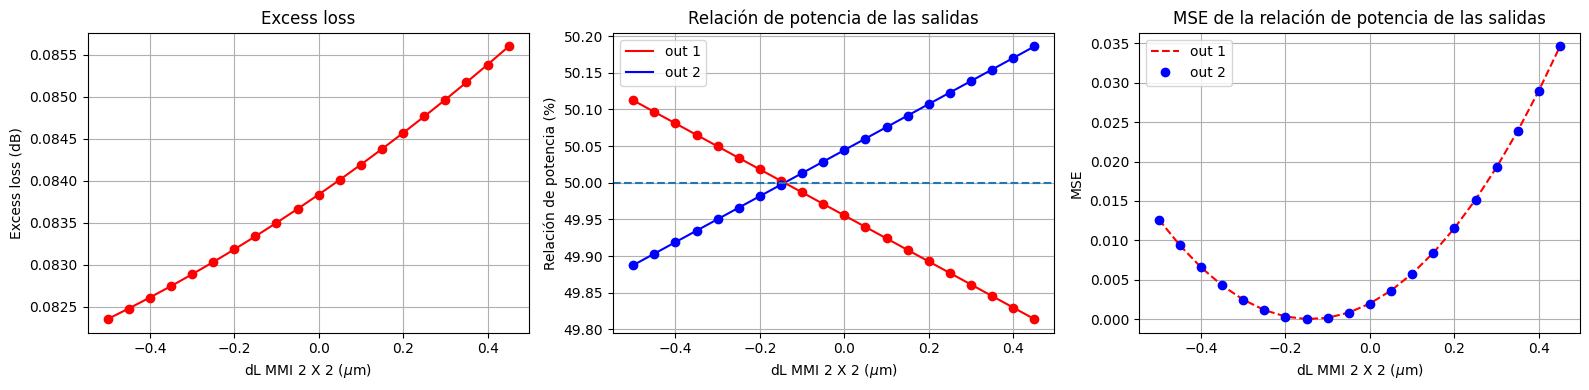

In [28]:

fig, axs = plt.subplots(1, 3, figsize=(16, 4))


axs[0].plot(array_DL_MMI, array_EL, 'r') 
axs[0].plot(array_DL_MMI, array_EL, 'o',linestyle='None',color='r') 
axs[0].set_title('Excess loss')
axs[0].set_xlabel(r'dL MMI 2 X 2 ($\mu$m)')
axs[0].set_ylabel('Excess loss (dB)')
axs[0].grid(True)

axs[1].plot(array_DL_MMI, array_power_out1, 'r',label='out 1') 
axs[1].plot(array_DL_MMI, array_power_out2, 'b',label='out 2')
axs[1].plot(array_DL_MMI, array_power_out1, 'o',color='r',linestyle='None') 
axs[1].plot(array_DL_MMI, array_power_out2, 'o',color='b',linestyle='None')
axs[1].axhline(y=50, linestyle='--', linewidth=1.5)
axs[1].ticklabel_format(axis='y', style='plain', useOffset=False)
axs[1].set_title('Relación de potencia de las salidas')
axs[1].set_xlabel(r'dL MMI 2 X 2 ($\mu$m)')
axs[1].set_ylabel('Relación de potencia (%)')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(array_DL_MMI, (np.array(array_power_out1)-50)**2, 'r--',label='out 1') 
axs[2].plot(array_DL_MMI, (np.array(array_power_out2)-50)**2, 'bo',label='out 2')
#axs[2].ticklabel_format(axis='y', style='plain', useOffset=False)
axs[2].set_title('MSE de la relación de potencia de las salidas')
axs[2].set_xlabel(r'dL MMI 2 X 2 ($\mu$m)')
axs[2].set_ylabel(r'MSE') # ($\times 10^{-4}$)
axs[2].legend()
axs[2].grid(True)



plt.tight_layout()

plt.show()

In [27]:
print('Las perdidas son: ', np.round(array_EL[7],3), "dB . Para un valor de dy = ", array_DL_MMI[7] )
print('El valor mínimo de la relación de potencias es: ', np.round( array_power_out1[7],3 ))
print('El valor máximo de la relación de potencias es: ', np.round( array_power_out2[7],3 ))

Las perdidas son:  0.083 dB . Para un valor de dy =  -0.15
El valor mínimo de la relación de potencias es:  50.003
El valor máximo de la relación de potencias es:  49.997


En este caso es necesario disminuir un poco la longitud del MMI para así encontrar el punto de cruce de las potencias de salida. Esto tambien permite disminuir las perdidas un poco, aunque como se observa la longitud no esta impactando tanto en las perdidas. Así, para la optimización del MMI se tiene que:

$ dL_{2x2} = -0.15 $                                           
$ dy_{input_{2x2}}=0.06 $                                      
$ dy_{out_{2x2}}=0.09 $                                     

## Compotamiento del MMI en una ventana de 100 nm:

In [35]:

mmi_Width = 5.5 
L_pi_wvl=[] # array para guardar el L_pi para cada una de las longitudes de onda

array_EL_c2=[]
array_power_out1_c2=[]
array_power_out2_c2=[]
array_phase_out1_c2=[]
array_phase_out2_c2=[]
array_phase_o1_o2_c2=[]


dy_input_c2=0.06
dy_out_c2=0.09

wvl_c = (1/1000)*np.linspace(1500, 1600, 10)# STUDENT code goes here

# m = MMI_EME(VERBOSE=True)  
for i in range(0,10,1):
    m = MMI_EME() 
    m.wvl = wvl_c[i]
    m.MMI_width = mmi_Width
    m.wg_width_dw = 0.5 
    m.MMI_num_modes = 30 
                     
    m.find_all_modes()
    L_pi_wvl.append(m.get_L_pi())

    m.n_IN =  2
    m.n_OUT = 2

    m.L_MMI = L_pi/2
    m.dL_MMI = -0.15

    m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy_input_c2, dy_input_c2]) # STUDENT
    m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy_out_c2, dy_out_c2]) # STUDENT
    power, power_total,power_in, phase=m.propagation()

    #Perdidas
    Loss = 10 * np.log10(power_in / power_total)
    array_EL_c2.append(Loss)


    array_power_out1_c2.append((power[0]*100)/power_total)
    array_power_out2_c2.append((power[1]*100)/power_total)
 
    array_phase_out1_c2.append(phase[0])
    array_phase_out2_c2.append(phase[1])
    array_phase_o1_o2_c2.append(phase[1]-phase[0])

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/485 [00:00<?, ?it/s]

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/6 [00:00<?, ?it/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/485 [00:00<?, ?it/s]

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/485 [00:00<?, ?it/s]

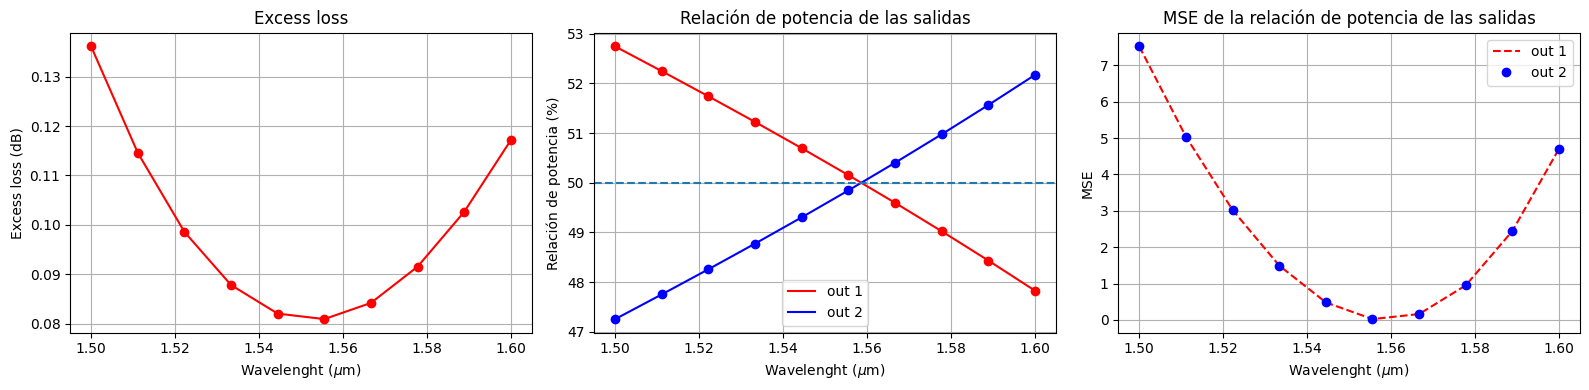

In [36]:

fig, axs = plt.subplots(1, 3, figsize=(16, 4))


axs[0].plot(wvl_c, array_EL_c2, 'r') 
axs[0].plot(wvl_c, array_EL_c2, 'o',linestyle='None',color='r') 
axs[0].set_title('Excess loss')
axs[0].set_xlabel(r'Wavelenght ($\mu$m)')
axs[0].set_ylabel('Excess loss (dB)')
axs[0].grid(True)

axs[1].plot(wvl_c, array_power_out1_c2, 'r',label='out 1') 
axs[1].plot(wvl_c, array_power_out2_c2, 'b',label='out 2')
axs[1].plot(wvl_c, array_power_out1_c2, 'o',color='r',linestyle='None') 
axs[1].plot(wvl_c, array_power_out2_c2, 'o',color='b',linestyle='None')
axs[1].axhline(y=50, linestyle='--', linewidth=1.5)
axs[1].ticklabel_format(axis='y', style='plain', useOffset=False)
axs[1].set_title('Relación de potencia de las salidas')
axs[1].set_xlabel(r'Wavelenght ($\mu$m)')
axs[1].set_ylabel('Relación de potencia (%)')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(wvl_c, (np.array(array_power_out1_c2)-50)**2, 'r--',label='out 1') 
axs[2].plot(wvl_c, (np.array(array_power_out2_c2)-50)**2, 'o',label='out 2',color='b')
#axs[2].plot(wvl_c, (np.array(array_power_out1_c2)-50)**2*1e4, 'o',color='r',linestyle='None') 
#axs[2].plot(wvl_c, (np.array(array_power_out2_c2)-50)**2*1e4, 'o',color='b',linestyle='None')
#axs[2].ticklabel_format(axis='y', style='plain', useOffset=False)
axs[2].set_title('MSE de la relación de potencia de las salidas')
axs[2].set_xlabel(r'Wavelenght ($\mu$m)')
axs[2].set_ylabel(r'MSE')
axs[2].legend()
axs[2].grid(True)




plt.tight_layout()

plt.show()

In [37]:
indice_max = array_EL_c2.index(max(array_EL_c2))
perdida_pot=10**(-array_EL_c2[indice_max]/10)

print("Las perdidas máximas se dan en la longitud de onda: ", wvl_c[indice_max]*1000, "nm, y son de: ", np.round(array_EL_c2[indice_max],3))
print("En esa longitud de onda se transmitirá el ", np.round(perdida_pot*100,3) , "% de la señal")
print("El máximo MSE ", np.round(np.max((np.array(array_power_out2_c2)-50)**2),3), 'x 10^-4')


Las perdidas máximas se dan en la longitud de onda:  1500.0 nm, y son de:  0.136
En esa longitud de onda se transmitirá el  96.914 % de la señal
El máximo MSE  7.52 x 10^-4
